In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle

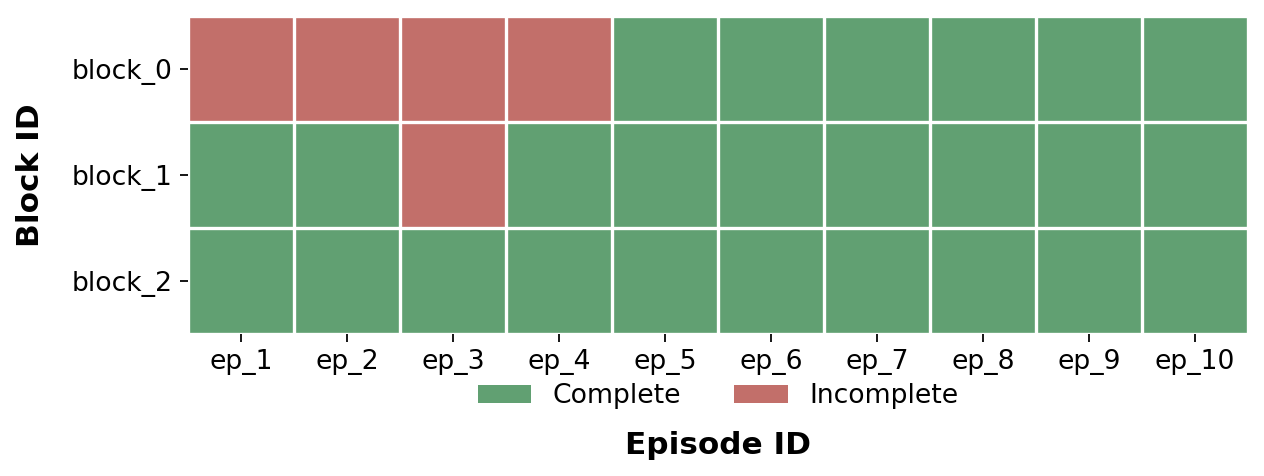

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Load CSV
df = pd.read_csv("block_presence_binary_ours.csv")

# Extract matrix
block_cols = [c for c in df.columns if c.startswith("Block_")]
matrix = df[block_cols].T.values
episodes = df["Episode"].tolist()
blocks = block_cols

# Morandi palette
morandi_red = "#C26F6A"    # Incomplete
morandi_green = "#61A072"  # Complete
bg_sand = "#F4F1ED"
cmap = ListedColormap([morandi_red, morandi_green])

# Plot with smaller width (2/3 length of before)
plt.figure(figsize=(8, 6), dpi=160)   # reduced width, kept height
ax = plt.gca()
ax.set_facecolor(bg_sand)

im = ax.imshow(matrix, cmap=cmap, aspect="equal", interpolation="nearest")

# Axis labels
ax.set_xlabel("Episode ID", labelpad=25, fontsize=14, weight="bold")
ax.set_ylabel("Block ID", labelpad=12, fontsize=14, weight="bold")

# Tick labels
ax.set_xticks(np.arange(len(episodes)))
ax.set_xticklabels([f"ep_{i}" for i in range(1, len(episodes) + 1)], fontsize=12, rotation=0)
ax.set_yticks(np.arange(len(blocks)))
ax.set_yticklabels([f"block_{i}" for i in range(len(blocks))], fontsize=12)

# Strong white gridlines
for x in range(len(episodes) + 1):
    ax.axvline(x - 0.5, color="white", linewidth=1.5)
for y in range(len(blocks) + 1):
    ax.axhline(y - 0.5, color="white", linewidth=1.5)

# Clean spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Custom legend below plot but above x-axis labels
legend_handles = [
    Patch(facecolor=morandi_green, label="Complete"),
    Patch(facecolor=morandi_red, label="Incomplete"),
]
ax.legend(handles=legend_handles,
          loc="upper center",
          bbox_to_anchor=(0.5, -0.08),
          ncol=2,
          frameon=False,
          fontsize=12)

plt.tight_layout()
plt.show()


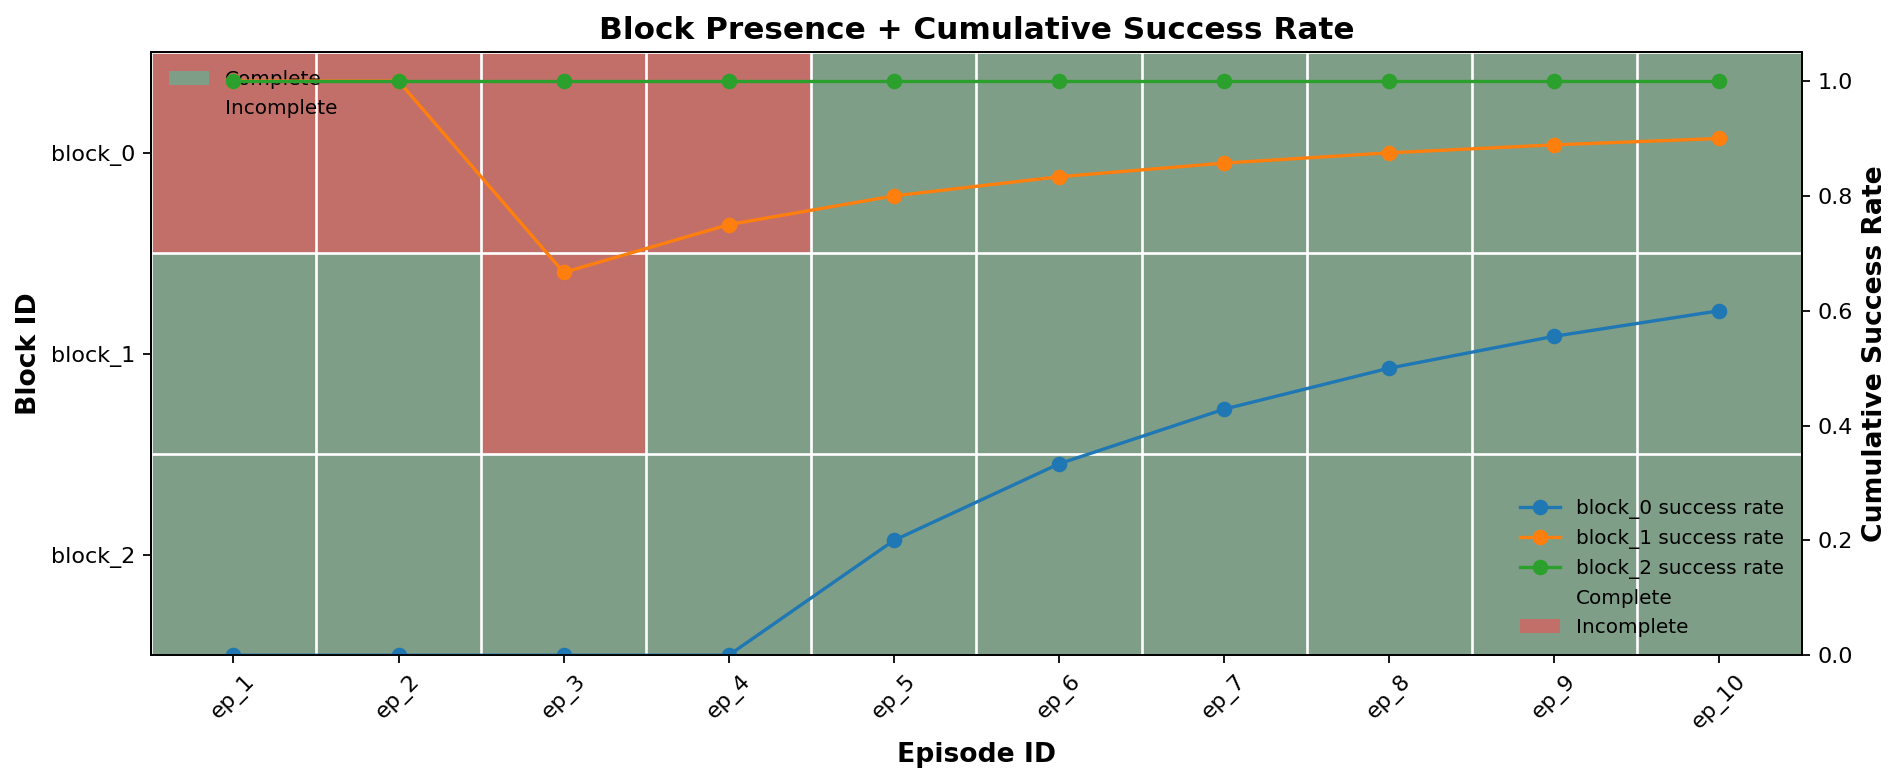

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Recreate dataset
data = {
    "Episode": [f"ep_{i}" for i in range(1, 11)],
    "block_0": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
    "block_1": [1, 1, 0, 1, 1, 1, 1, 1, 1, 1],
    "block_2": [1] * 10,
}
df = pd.DataFrame(data)

block_cols = [c for c in df.columns if c.startswith("block_")]
matrix = df[block_cols].T.values
episodes = df["Episode"].tolist()
blocks = block_cols

# Morandi palette
morandi_red = "#C26F6A"
morandi_green = "#7E9E87"
bg_sand = "#F4F1ED"
cmap = ListedColormap([morandi_red, morandi_green])

# Create figure
fig, ax1 = plt.subplots(figsize=(12, 5), dpi=160)
ax1.set_facecolor(bg_sand)

# Plot heatmap
im = ax1.imshow(matrix, cmap=cmap, aspect="auto", interpolation="nearest")

# Heatmap axis formatting
ax1.set_xticks(np.arange(len(episodes)))
ax1.set_xticklabels(episodes, fontsize=10, rotation=45)
ax1.set_yticks(np.arange(len(blocks)))
ax1.set_yticklabels(blocks, fontsize=10)
ax1.set_xlabel("Episode ID", fontsize=12, weight="bold")
ax1.set_ylabel("Block ID", fontsize=12, weight="bold")

# Gridlines for heatmap
for x in range(len(episodes) + 1):
    ax1.axvline(x - 0.5, color="white", linewidth=1.2)
for y in range(len(blocks) + 1):
    ax1.axhline(y - 0.5, color="white", linewidth=1.2)

# Legend for heatmap
legend_handles = [
    Patch(facecolor=morandi_green, label="Complete"),
    Patch(facecolor=morandi_red, label="Incomplete"),
]
ax1.legend(handles=legend_handles, loc="upper left", fontsize=9, frameon=False)

# Second y-axis for cumulative success rate
ax2 = ax1.twinx()

# Compute cumulative success rates
cum_rates = df.copy()
for col in block_cols:
    cum_rates[col] = df[col].cumsum() / (df.index + 1)

for col in block_cols:
    ax2.plot(np.arange(len(episodes)), cum_rates[col],
             marker="o", label=f"{col} success rate")

ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Cumulative Success Rate", fontsize=12, weight="bold")

# Combined legend (heatmap + lines)
lines_labels = ax2.get_legend_handles_labels()
ax2.legend(lines_labels[0] + legend_handles,
           lines_labels[1] + ["Complete", "Incomplete"],
           loc="lower right", fontsize=9, frameon=False)

plt.title("Block Presence + Cumulative Success Rate", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()
